In [1]:
# source => https://mitu.co.in/dataset
# data => Salary_Data.csv

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("Salary_Data.csv")
df.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [5]:
df.shape

(30, 2)

In [6]:
df.isna().sum()

YearsExperience    0
Salary             0
dtype: int64

In [7]:
df.columns

Index(['YearsExperience', 'Salary'], dtype='object')

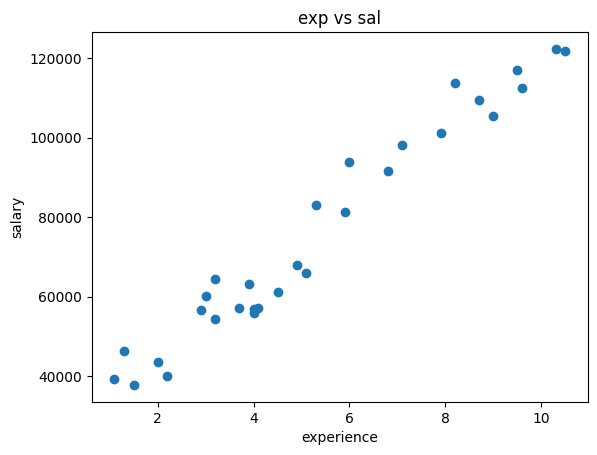

In [8]:
plt.title("exp vs sal")
plt.xlabel("experience")
plt.ylabel("salary")
plt.scatter(df['YearsExperience'], df['Salary']);

In [9]:
# separate input and output
# i/p -> 2d,  o/p -> 1d

x = df[['YearsExperience']]
y = df['Salary']

In [10]:
x.ndim

2

In [11]:
# cross validation

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
x_train, x_test, y_train, y_test = train_test_split(x, y,
                                                   random_state= 0,
                                                   test_size= 0.25)

In [14]:
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((22, 1), (22,), (8, 1), (8,))

In [15]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

In [16]:
lr.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [17]:
lr.coef_

array([9379.71049195])

In [18]:
lr.intercept_

np.float64(26986.691316737248)

In [19]:
# eval

In [20]:
y_pred = lr.predict(x_test)

In [21]:
y_pred

array([ 41056.25705466, 123597.70938378,  65443.50433372,  63567.56223533,
       116093.94099022, 108590.17259667, 117031.91203942,  64505.53328452])

In [22]:
# create a dataframe to compare actual and predicted values

In [23]:
pd.DataFrame({
    'actual': y_test,
    'predicted': y_pred
})

,actual,predicted
2,37731.0,41056.257055
28,122391.0,123597.709384
13,57081.0,65443.504334
10,63218.0,63567.562235
26,116969.0,116093.940990
24,109431.0,108590.172597
27,112635.0,117031.912039
11,55794.0,64505.533285


In [24]:
from sklearn.metrics import mean_absolute_error

mean_absolute_error(y_test, y_pred)

3508.5455930660555

In [25]:
from sklearn.metrics import r2_score
r2_score(y_test, y_pred)

0.9779208335417602

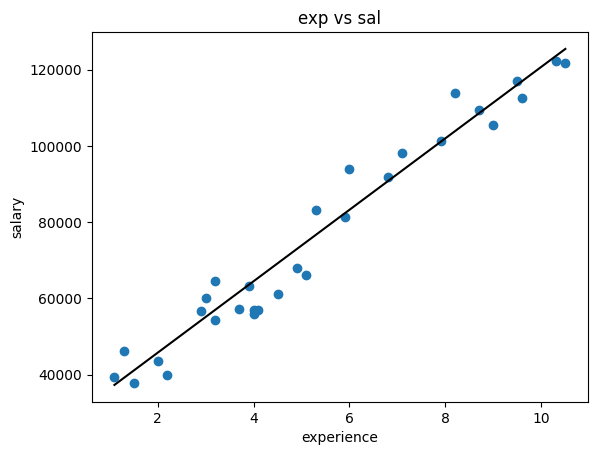

In [28]:
plt.title("exp vs sal")
plt.xlabel("experience")
plt.ylabel("salary")
plt.scatter(df['YearsExperience'], df['Salary']);
plt.plot(x, lr.predict(x), color = 'black')